In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('sales_data_sample.csv', encoding='latin1')

### Uploading a file to Google Colab

You can upload files directly to your Colab session using `files.upload()`.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving sales_data_sample.csv to sales_data_sample.csv
User uploaded file "sales_data_sample.csv" with length 527958 bytes


After running the cell, a 'Choose Files' button will appear. Click it, then navigate to and select your `sales_data_sample.csv` file. Once uploaded, the file will be accessible in the Colab environment. You can then modify your `pd.read_csv()` call to use the uploaded file's name directly, like this:

```python
df = pd.read_csv('sales_data_sample.csv')
```

Alternatively, if you want to use files stored in your Google Drive, you can mount your Drive using the following code:

```python
from google.colab import drive
drive.mount('/content/drive')
```

Once mounted, your Google Drive files will be accessible under `/content/drive/My Drive/`.

# Intro with dataset

In [ ]:
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,12/2/2004 0:00,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,1/31/2005 0:00,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,3/1/2005 0:00,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,3/28/2005 0:00,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [ ]:
df.shape

(2823, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [ ]:
df['ORDERDATE']= pd.to_datetime(df['ORDERDATE'])

In [ ]:
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,2004-12-02,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,2005-01-31,Shipped,1,1,2005,...,Torikatu 38,NaN,Oulu,NaN,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,2005-03-01,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,2005-03-28,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,NaN,Toulouse,NaN,31000,France,EMEA,Roulet,Annette,Small


In [ ]:
df.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2004-05-11 00:16:49.989373056,2.717676,7.092455,2003.81509,100.715551
min,10100.000000,6.000000,26.880000,1.000000,482.130000,2003-01-06 00:00:00,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2003-11-06 12:00:00,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,2004-06-15 00:00:00,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,2004-11-17 12:00:00,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,2005-05-31 00:00:00,4.000000,12.000000,2005.00000,214.000000
std,92.085478,9.741443,20.174277,4.225841,1841.865106,NaN,1.203878,3.656633,0.69967,40.187912


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df[df['PHONE'].isnull()== True]


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE


# **Null Handling**

In [ ]:
df['PHONE'] = df['PHONE'].fillna('Unknown')
df['ADDRESSLINE2'] = df['ADDRESSLINE2'].fillna('Unknown')
df['STATE'] = df['STATE'].fillna('Unknown')
df['POSTALCODE'] = df['POSTALCODE'].fillna('Unknown')
df['TERRITORY'] = df['TERRITORY'].fillna('Unknown')

In [ ]:
df

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,...,897 Long Airport Avenue,Unknown,NYC,NY,10022,USA,Unknown,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,...,59 rue de l'Abbaye,Unknown,Reims,Unknown,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,Unknown,Paris,Unknown,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,...,78934 Hillside Dr.,Unknown,Pasadena,CA,90003,USA,Unknown,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,...,7734 Strong St.,Unknown,San Francisco,CA,Unknown,USA,Unknown,Brown,Julie,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,10350,20,100.00,15,2244.40,2004-12-02,Shipped,4,12,2004,...,"C/ Moralzarzal, 86",Unknown,Madrid,Unknown,28034,Spain,EMEA,Freyre,Diego,Small
2819,10373,29,100.00,1,3978.51,2005-01-31,Shipped,1,1,2005,...,Torikatu 38,Unknown,Oulu,Unknown,90110,Finland,EMEA,Koskitalo,Pirkko,Medium
2820,10386,43,100.00,4,5417.57,2005-03-01,Resolved,1,3,2005,...,"C/ Moralzarzal, 86",Unknown,Madrid,Unknown,28034,Spain,EMEA,Freyre,Diego,Medium
2821,10397,34,62.24,1,2116.16,2005-03-28,Shipped,1,3,2005,...,1 rue Alsace-Lorraine,Unknown,Toulouse,Unknown,31000,France,EMEA,Roulet,Annette,Small


In [ ]:
df.value_counts('STATUS')

,count
STATUS,
Shipped,2617
Cancelled,60
Resolved,47
On Hold,44
In Process,41
Disputed,14


In [ ]:
df.value_counts('STATUS', normalize= True)

,proportion
STATUS,
Shipped,0.927028
Cancelled,0.021254
Resolved,0.016649
On Hold,0.015586
In Process,0.014524
Disputed,0.004959


In [ ]:

df.value_counts('PRODUCTLINE')

,count
PRODUCTLINE,
Classic Cars,967
Vintage Cars,607
Motorcycles,331
Planes,306
Trucks and Buses,301
Ships,234
Trains,77


In [ ]:
df.value_counts('PRODUCTLINE', normalize= True)

,proportion
PRODUCTLINE,
Classic Cars,0.342543
Vintage Cars,0.215019
Motorcycles,0.117251
Planes,0.108395
Trucks and Buses,0.106624
Ships,0.082891
Trains,0.027276


In [ ]:
df.value_counts('YEAR_ID')


,count
YEAR_ID,
2004,1345
2003,1000
2005,478


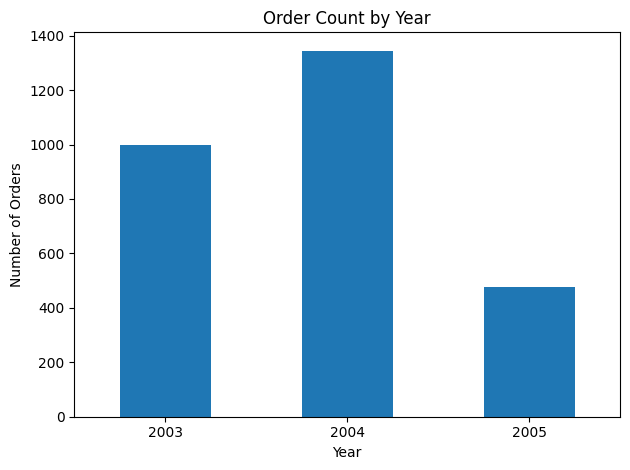

In [ ]:
import matplotlib.pyplot as plt

orders_by_year = df.groupby("YEAR_ID")["ORDERNUMBER"].count()

orders_by_year.plot(kind="bar")

plt.title("Order Count by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [ ]:
df.value_counts('YEAR_ID', normalize= True)

,proportion
YEAR_ID,
2004,0.476443
2003,0.354233
2005,0.169323


In [ ]:
result = df.groupby(['STATUS','YEAR_ID'])['ORDERNUMBER'].count()
result

STATUS      YEAR_ID
Cancelled   2003         16
            2004         44
Disputed    2005         14
In Process  2005         41
On Hold     2004          6
            2005         38
Resolved    2003          8
            2004          8
            2005         31
Shipped     2003        976
            2004       1287
            2005        354
Name: ORDERNUMBER, dtype: int64

Demeli bu verilenlere uygun bir nece business insight yazmaliyam

In [ ]:
##Python sehv edesi deyil amma yene de cemi 2823 edir mi yoxlamaq istedim
b=0

a= [16,44,14,41,6,38,8,8,31,976,1287,354]
for i in a:
  b=b+i
  print(b)

16
60
74
115
121
159
167
175
206
1182
2469
2823


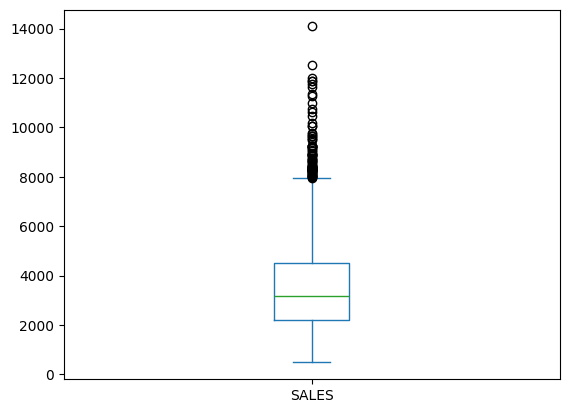

In [ ]:
# Boxplot ilə baxmaq üçün (vizual)
import matplotlib.pyplot as plt

df["SALES"].plot(kind="box")
plt.show()

In [ ]:
q1, q3 = np.quantile(df['SALES'], [0.25, 0.75])
IQR = q3 - q1
print(q1)
print(q3)
print(IQR)

2203.4300000000003
4508.0
2304.5699999999997


In [ ]:
top_five = df.groupby('COUNTRY')['ORDERNUMBER'].count().sort_values(ascending= False).head()
top_five



,ORDERNUMBER
COUNTRY,
USA,1004
Spain,342
France,314
Australia,185
UK,144


a bar chart showing top 5 countries by order count

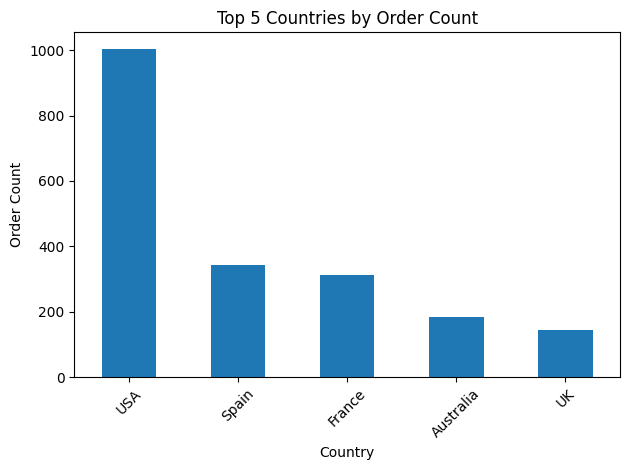

In [ ]:
# Bar chart
top_five.plot(kind="bar")

plt.title("Top 5 Countries by Order Count")
plt.xlabel("Country")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

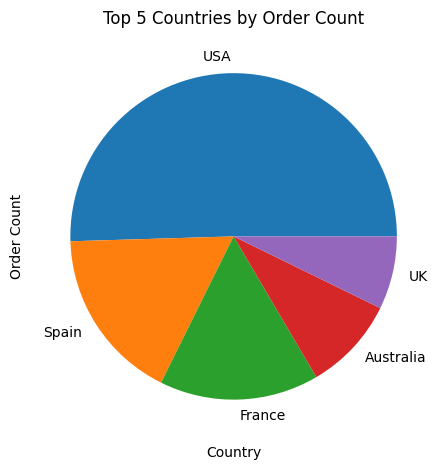

In [ ]:
##sadece ne qeder informativ olub, olmadigini yoxlamaq istedim
top_five.plot(kind="pie")

plt.title("Top 5 Countries by Order Count")
plt.xlabel("Country")
plt.ylabel("Order Count")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Sadəcə müəyyən ölkəyə aid sifarişləri göstər (məs: USA)

10000-dən böyük satışları filter et

Ən yüksək satış olan 10 sifarişi tap

Müəyyən bir məhsul xəttinə (product line) görə filter et

In [ ]:
df[df['COUNTRY'] == 'USA']['TERRITORY'].value_counts()

,count
TERRITORY,


In [ ]:
df[df['COUNTRY'] == 'Canada']['TERRITORY'].value_counts()

,count
TERRITORY,


In [ ]:
1407+221+121+1004


2753

In [ ]:
df['COUNTRY'].value_counts()

# olkelere baxdim elimde 70 null qalmisdi deye kanadaya uygun geleceyini dusundum ele de oldu

,count
COUNTRY,
USA,1004
Spain,342
France,314
Australia,185
UK,144
Italy,113
Finland,92
Norway,85
Singapore,79


USA-ya aid olan butun territory columnlari nulldur, amma territorydeki butun nullar tekce USA-da deyil
70-i kanadadi
1004- usada

In [ ]:
df['TERRITORY'].value_counts()

,count
TERRITORY,
EMEA,1407
APAC,221
Japan,121


10000-dən böyük satışları filter et

In [ ]:
df[df['SALES'] > 10000].groupby('COUNTRY')['ORDERNUMBER'].count()

,ORDERNUMBER
COUNTRY,
Denmark,1
Finland,1
France,3
Japan,1
Singapore,1
Spain,2
UK,1
USA,6


In [ ]:
df['SALES'].groupby(df['COUNTRY']).sum().sort_values(ascending= False)

,SALES
COUNTRY,
USA,3627982.83
Spain,1215686.92
France,1110916.52
Australia,630623.10
UK,478880.46
Italy,374674.31
Finland,329581.91
Norway,307463.70
Singapore,288488.41


In [ ]:
##Ümumi satışdakı paylarını tapmaq(faizlə)
(df['SALES'].groupby(df['COUNTRY']).count().sort_values(ascending= False)/2823)*100

,SALES
COUNTRY,
USA,35.565002
Spain,12.114772
France,11.122919
Australia,6.553312
UK,5.100956
Italy,4.002834
Finland,3.258944
Norway,3.010981
Singapore,2.798441


In [ ]:
df['SALES'].groupby(df['COUNTRY']).count().sort_values(ascending= False)

,SALES
COUNTRY,
USA,1004
Spain,342
France,314
Australia,185
UK,144
Italy,113
Finland,92
Norway,85
Singapore,79


In [ ]:
(df['SALES'].groupby(df['COUNTRY']).sum().sort_values(ascending= False)/df['SALES'].groupby(df['COUNTRY']).count().sort_values(ascending= False)).sort_values(ascending=False)

,SALES
COUNTRY,
Denmark,3899.002381
Switzerland,3797.211613
Sweden,3684.459825
Austria,3673.864182
Singapore,3651.752025
Japan,3618.611731
Norway,3617.220000
Philippines,3615.989615
USA,3613.528715


In [ ]:
df['SALES'].sum()

np.float64(10032628.85)

Bunu niye yazmisam xatirlamiram. Amma bunu cixardim ki, Denmark daha cox qazanc getirir cunki sifarishlerin meblegi coxdu




In [ ]:
df[df['COUNTRY'] == 'Denmark']['SALES'].count()

np.int64(63)

In [ ]:
## bu yarimciq qaldi
df[df['COUNTRY'] == 'Denmark']['SALES'] > 5000

,SALES
106,True
172,True
186,True
203,True
283,True
...,...
2710,False
2717,False
2736,False
2797,False


In [ ]:
## Ən yüksək satış olan 10 sifarişi tap

In [ ]:
df.sort_values('SALES' , ascending= False).head(10)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
598,10407,76,100.0,2,14082.8,2005-04-22,On Hold,2,4,2005,...,3086 Ingle Ln.,NaN,San Jose,CA,94217,USA,NaN,Frick,Sue,Large
744,10322,50,100.0,6,12536.5,2004-11-04,Shipped,4,11,2004,...,2304 Long Airport Avenue,NaN,Nashua,NH,62005,USA,NaN,Young,Valarie,Large
53,10424,50,100.0,6,12001.0,2005-05-31,In Process,2,5,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Large
1062,10412,60,100.0,9,11887.8,2005-05-03,Shipped,2,5,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Large
104,10403,66,100.0,9,11886.6,2005-04-08,Shipped,2,4,2005,...,Berkeley Gardens 12 Brewery,NaN,Liverpool,NaN,WX1 6LT,UK,EMEA,Devon,Elizabeth,Large
1995,10405,76,100.0,3,11739.7,2005-04-14,Shipped,2,4,2005,...,"24, place Kluber",NaN,Strasbourg,NaN,67000,France,EMEA,Citeaux,Frederique,Large
44,10312,48,100.0,3,11623.7,2004-10-21,Shipped,4,10,2004,...,5677 Strong St.,NaN,San Rafael,CA,97562,USA,NaN,Nelson,Valarie,Large
1133,10333,46,100.0,2,11336.7,2004-11-18,Shipped,4,11,2004,...,5557 North Pendale Street,NaN,San Francisco,CA,NaN,USA,NaN,Murphy,Julie,Large
188,10127,46,100.0,2,11279.2,2003-06-03,Shipped,2,6,2003,...,4092 Furth Circle,Suite 400,NYC,NY,10022,USA,NaN,Young,Jeff,Large
30,10150,45,100.0,8,10993.5,2003-09-19,Shipped,3,9,2003,...,"Bronz Sok., Bronz Apt. 3/6 Tesvikiye",NaN,Singapore,NaN,79903,Singapore,Japan,Natividad,Eric,Large


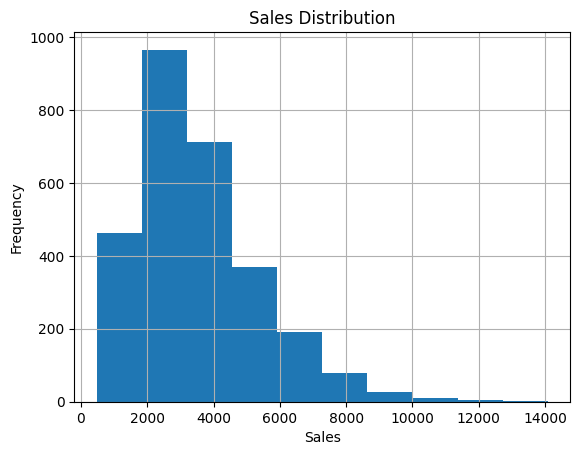

In [ ]:
import matplotlib.pyplot as plt

df["SALES"].hist()

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df.sort_values('ORDERDATE' , ascending= False).head(10)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
1667,10425,49,100.00,9,5510.54,2005-05-31,In Process,2,5,2005,...,"67, rue des Cinquante Otages",NaN,Nantes,NaN,44000,France,EMEA,Labrune,Janine,Medium
727,10425,38,99.41,7,3777.58,2005-05-31,In Process,2,5,2005,...,"67, rue des Cinquante Otages",NaN,Nantes,NaN,44000,France,EMEA,Labrune,Janine,Medium
2302,10424,44,61.41,2,2702.04,2005-05-31,In Process,2,5,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Small
2405,10425,18,100.00,2,1895.94,2005-05-31,In Process,2,5,2005,...,"67, rue des Cinquante Otages",NaN,Nantes,NaN,44000,France,EMEA,Labrune,Janine,Small
2249,10425,11,43.83,6,482.13,2005-05-31,In Process,2,5,2005,...,"67, rue des Cinquante Otages",NaN,Nantes,NaN,44000,France,EMEA,Labrune,Janine,Small
2172,10425,41,86.68,11,3553.88,2005-05-31,In Process,2,5,2005,...,"67, rue des Cinquante Otages",NaN,Nantes,NaN,44000,France,EMEA,Labrune,Janine,Medium
160,10425,38,100.00,12,5894.94,2005-05-31,In Process,2,5,2005,...,"67, rue des Cinquante Otages",NaN,Nantes,NaN,44000,France,EMEA,Labrune,Janine,Medium
1743,10425,31,33.24,5,1030.44,2005-05-31,In Process,2,5,2005,...,"67, rue des Cinquante Otages",NaN,Nantes,NaN,44000,France,EMEA,Labrune,Janine,Small
239,10424,49,100.00,3,7969.36,2005-05-31,In Process,2,5,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Large
53,10424,50,100.00,6,12001.00,2005-05-31,In Process,2,5,2005,...,"C/ Moralzarzal, 86",NaN,Madrid,NaN,28034,Spain,EMEA,Freyre,Diego,Large


In [ ]:
df.groupby(["COUNTRY", "YEAR_ID"])["SALES"].sum()

COUNTRY      YEAR_ID
Australia    2003        253134.45
             2004        232396.68
             2005        145091.97
Austria      2003         82117.88
             2004         51694.39
             2005         68250.26
Belgium      2003          3348.46
             2004         80024.05
             2005         25040.11
Canada       2003         54609.50
             2004        135776.09
             2005         33692.97
Denmark      2003         99192.72
             2004        120431.56
             2005         26012.87
Finland      2003        111154.51
             2004         91575.69
             2005        126851.71
France       2003        312761.42
             2004        555198.70
             2005        242956.40
Germany      2003         70053.31
             2004        150418.78
Ireland      2004         57756.43
Italy        2003        140928.77
             2004        192235.60
             2005         41509.94
Japan        2004        149422.47
             2005         38745.34
Norway       2003        196532.60
             2004        110931.10
Philippines  2003         78086.98
             2004         15928.75
Singapore    2003        165686.20
             2004        116039.03
             2005          6763.18
Spain        2003        405343.39
             2004        483545.36
             2005        326798.17
Sweden       2003         58459.92
             2004        119947.57
             2005         31606.72
Switzerland  2004        117713.56
UK           2003        180421.55
             2004        257656.10
             2005         40802.81
USA          2003       1305147.88
             2004       1685470.69
             2005        637364.26
Name: SALES, dtype: float64

In [ ]:
result_2= df.groupby(["COUNTRY", "YEAR_ID"])["SALES"].sum().sort_values(ascending= False)
result_2

COUNTRY      YEAR_ID
USA          2004       1685470.69
             2003       1305147.88
             2005        637364.26
France       2004        555198.70
Spain        2004        483545.36
             2003        405343.39
             2005        326798.17
France       2003        312761.42
UK           2004        257656.10
Australia    2003        253134.45
France       2005        242956.40
Australia    2004        232396.68
Norway       2003        196532.60
Italy        2004        192235.60
UK           2003        180421.55
Singapore    2003        165686.20
Germany      2004        150418.78
Japan        2004        149422.47
Australia    2005        145091.97
Italy        2003        140928.77
Canada       2004        135776.09
Finland      2005        126851.71
Denmark      2004        120431.56
Sweden       2004        119947.57
Switzerland  2004        117713.56
Singapore    2004        116039.03
Finland      2003        111154.51
Norway       2004        110931.10
Denmark      2003         99192.72
Finland      2004         91575.69
Austria      2003         82117.88
Belgium      2004         80024.05
Philippines  2003         78086.98
Germany      2003         70053.31
Austria      2005         68250.26
Sweden       2003         58459.92
Ireland      2004         57756.43
Canada       2003         54609.50
Austria      2004         51694.39
Italy        2005         41509.94
UK           2005         40802.81
Japan        2005         38745.34
Canada       2005         33692.97
Sweden       2005         31606.72
Denmark      2005         26012.87
Belgium      2005         25040.11
Philippines  2004         15928.75
Singapore    2005          6763.18
Belgium      2003          3348.46
Name: SALES, dtype: float64

In [ ]:
import matplotlib.pyplot as plt

# result_2 is already defined in a previous cell as a Series with MultiIndex (COUNTRY, YEAR_ID)
# and its values are the sum of sales, globally sorted in descending order.

# To find the top 5 countries by sales for each year, we can group by YEAR_ID
# and then use nlargest(5) to get the top 5 sales within each year.
top = (
    result_2.groupby(level='YEAR_ID', group_keys=False)
    .nlargest(5)
)

# The 'top' Series now has a MultiIndex (YEAR_ID, COUNTRY).
# Iterate through each unique year in the index.
for year in top.index.get_level_values('YEAR_ID').unique().sort_values():
    # Select the subset of data for the current year using .xs() for cross-section indexing.
    # 'subset' will be a Series indexed by COUNTRY for the given year.
    subset = top.xs(year, level='YEAR_ID')

    plt.figure(figsize=(10, 6)) # Create a new figure for each plot
    plt.bar(subset.index, subset.values) # Plot countries (index) vs sales (values)

    plt.title(f"Top 5 Countries by Sales - {year}")
    plt.xlabel("COUNTRY")
    plt.ylabel("SALES")

    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

KeyError: 2003